# Graphic 2: GISTEMP Seasonal Cycle since 1880

This notebook replicates the GISTEMP v4 graphic
[GISTEMP Seasonal Cycle since 1880](https://data.giss.nasa.gov/gistemp/graphs_v4/graph_data/GISTEMP_Seasonal_Cycle_since_1880/graph.html).

The figure shows the average seasonal cycle of global surface temperature.
Every year is drawn as one line across the twelve months, and the lines are
coloured in 20-year bins so that the upward shift of the seasonal cycle over
time is visible.

**Data:** `data/seasonal_cycle.csv`
(monthly anomalies relative to the 1980-2015 base period).

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## Load and reshape the data

The `Year` column is a decimal year (e.g. `1880.04` is roughly mid-January
1880). Flooring it gives the calendar year; within each year the rows are in
month order, so `month` is the within-year row number.

In [2]:
df = pd.read_csv(DATA_DIR / "seasonal_cycle.csv", skiprows=1, header=0,
                 names=["Year", "Anomaly"])
df["year"] = df["Year"].astype(int)
df["month"] = df.groupby("year").cumcount() + 1

counts = df.groupby("year").size()
print("months per year (unique):", sorted(counts.unique()))
print("years:", df.year.min(), "-", df.year.max())
df.head()

months per year (unique): [np.int64(8), np.int64(12)]
years: 1880 - 2026


,Year,Anomaly,year,month
0,1880.04,-2.61,1880,1
1,1880.13,-2.42,1880,2
2,1880.21,-1.58,1880,3
3,1880.29,-0.64,1880,4
4,1880.38,0.36,1880,5


All years have 12 monthly values except the last (partial) year, which
contains only January-August 2026.

In [3]:
counts.tail()

year
2022    12
2023    12
2024    12
2025    12
2026     8
dtype: int64

## Build the figure

The colour bins used in the original graphic are:

| Years | Colour |
| --- | --- |
| 1880-1899 | `#5264FA` |
| 1900-1919 | `#3968E6` |
| 1920-1939 | `#4B9FBE` |
| 1940-1959 | `#73BD97` |
| 1960-1979 | `#94BD6B` |
| 1980-1999 | `#BD9C42` |
| 2000-2019 | `#E26332` |
| 2020-2025 | `#B1231F` |
| 2026 | `#730073` |

The current, incomplete year (2026) is additionally highlighted with black
markers at each monthly value.

Text(0.99, 0.01, 'Seasonal cycle from MERRA2. Figure: NASA/GISS/GISTEMP v4')

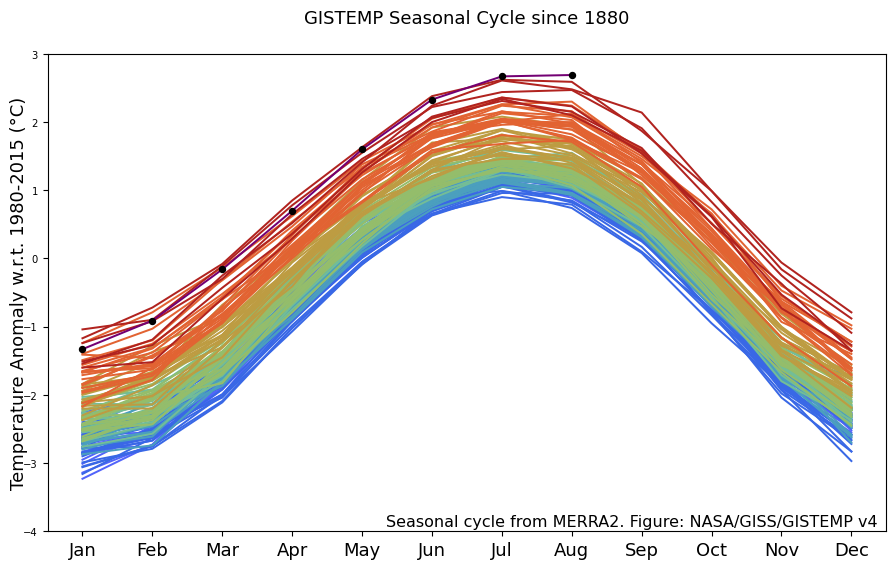

In [4]:
bins = [
    (1880, 1899, "#5264FA"), (1900, 1919, "#3968E6"), (1920, 1939, "#4B9FBE"),
    (1940, 1959, "#73BD97"), (1960, 1979, "#94BD6B"), (1980, 1999, "#BD9C42"),
    (2000, 2019, "#E26332"), (2020, 2025, "#B1231F"), (2026, 2100, "#730073"),
]


def color_for(year):
    for lo, hi, color in bins:
        if lo <= year <= hi:
            return color


fig = plt.figure(figsize=(9.04, 5.6), dpi=100)
ax = fig.add_axes([0.0606, 0.0586, 0.9279, 0.8525])

for year, group in df.groupby("year"):
    ax.plot(group.month, group.Anomaly, color=color_for(year), lw=1.44, zorder=1)

latest = df[df.year == df.year.max()]
ax.plot(latest.month, latest.Anomaly, "o", color="black", ms=4.3, zorder=5)

ax.set_xlim(0.5, 12.5)
ax.set_ylim(-4, 3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks([-4, -3, -2, -1, 0, 1, 2, 3])
ax.tick_params(axis="x", labelsize=12.96)
ax.tick_params(axis="y", labelsize=7.2)

ax.text(0.5, 1.064, "GISTEMP Seasonal Cycle since 1880", transform=ax.transAxes,
        ha="center", va="baseline", fontsize=12.96)
ax.text(-0.034, 0.5, "Temperature Anomaly w.r.t. 1980-2015 (\N{DEGREE SIGN}C)",
        transform=ax.transAxes, ha="center", va="center", rotation=90,
        fontsize=12.96)
ax.text(0.99, 0.01, "Seasonal cycle from MERRA2. Figure: NASA/GISS/GISTEMP v4",
        transform=ax.transAxes, ha="right", va="baseline", fontsize=11.52)

### Legend

The original legend is a small white box in the upper-left corner with a
coloured line swatch and a coloured year label for each bin.

In [5]:
box = FancyBboxPatch((0.0066, 0.688), 0.0880 - 0.0066, 0.9884 - 0.688,
                     boxstyle="round,pad=0,rounding_size=0.008",
                     transform=ax.transAxes, facecolor="white", alpha=0.8,
                     edgecolor="#cccccc", lw=0.72, zorder=6)
ax.add_patch(box)

legend_labels = ["1880", "1900", "1920", "1940", "1960",
                 "1980", "2000", "2020", "2026"]
for i, ((lo, hi, color), label) in enumerate(zip(bins, legend_labels)):
    y = 0.9704 - 0.0325 * i
    ax.plot([0.0119, 0.0384], [y, y], color=color, lw=1.44,
            transform=ax.transAxes, zorder=7, clip_on=False)
    ax.text(0.049, y, label, color=color, fontsize=7.2,
            transform=ax.transAxes, va="center", ha="left", zorder=7)

## Save and display

In [6]:
fig.savefig(OUTPUT_DIR / "graphic2_seasonal_cycle.png", dpi=100)
fig.savefig(OUTPUT_DIR / "graphic2_seasonal_cycle.pdf")
plt.show()

Each year traces the same seasonal shape, but the whole family of curves
shifts upward over time: recent years (red/purple) sit well above the early
years (blue). The 2026 line, highlighted in purple with black markers, is
based on a partial year (January-August).